## Running example from the readme


In [139]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_with_given_kernel_params(X, kernel_params, gpvae, n_samples=100):
    """
    Reconstructs data using GP-VAE with given kernel parameters, sampling multiple times from the latent distribution.

    Parameters:
    - X: Input data
    - kernel_params: List of kernel parameters
    - gpvae: Trained GP-VAE model
    - n_samples: Number of samples to draw from the latent Gaussian

    Returns:
    - x_input: The original input with NaNs for missing values
    - x_recon_mean: Mean reconstruction across samples
    - x_recon_min: Minimum reconstructed values across samples
    - x_recon_max: Maximum reconstructed values across samples
    """

    # Convert input to tensor
    x_input = torch.tensor(X).float()

    # Encode to obtain latent parameters (mean & variance)
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    # Plot the original latent mean
    plt.plot(z_mu[0].detach(), 'o', label="z_mu (mean)")
    plt.gca().set_prop_cycle(None)

    # Update kernel_params to match batch size and latent dimensions
    kernel_params = torch.tensor(kernel_params).reshape(1, 1, 4).repeat(z_mu.shape[0], z_mu.shape[2], 1)

    # Apply GP correction to latent space
    z_star, z_star_var = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params, return_variance=True)

    z_star_var = z_star_var.clamp(min=0.)
   
    # Plot corrected latent mean
    plt.plot(z_star[0].detach(), label="z_star (corrected)")
    plt.legend()
    plt.show()

    # Sample from Gaussian: z ~ N(z_star, z_star_var)
    z_samples = torch.randn((n_samples,) + z_star.shape) * torch.sqrt(z_star_var) + z_star

    # Decode each sampled latent representation
    x_recon_samples = gpvae.model.backbone.decode(z_samples).mean  # Shape: (n_samples, batch, seq, features)

    # Compute mean, min, and max across samples
    x_recon_mean = x_recon_samples.mean(dim=0)  # Average over n_samples
    x_recon_min = x_recon_samples.min(dim=0).values  # Minimum over n_samples
    x_recon_max = x_recon_samples.max(dim=0).values  # Maximum over n_samples

    # Mask missing values in x_input with NaNs
    x_input[x_input == 0] = torch.nan

    return x_input, x_recon_mean, x_recon_min, x_recon_max


In [279]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

# Parameters
n_groups = 1
n_observations_per_group = 1000
n_dimensions = 5
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

if False:
    # Plot example
    for dim in range(n_dimensions):
        for group_idx in range(n_groups):
            plt.figure()
            for observation in gp_samples[group_idx]:
                plt.plot(time_points, observation[:, dim], label=f"Dim {dim + 1}")
            plt.title(f"Group {group_idx + 1} Observations for Dimension {dim + 1}")
            plt.xlabel("Time")
            plt.ylabel("Value")
            plt.legend()
            plt.show()


100%|██████████| 1000/1000 [00:00<00:00, 1643.05it/s]


In [337]:
n_new_dims = 5
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

In [338]:
from pygrinder import mcar
# Normalize

p_dataset = .7

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

#plt.plot(X_ori[1]);

In [358]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 6, 
            epochs = 1000, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam(weight_decay=0.001, lr = 1e-4), #lr = 1e-4
            patience = 100
            )

gpvae.model.backbone.alpha = 1e0
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.noise_sigma = 1e-3
gpvae.model.backbone.sampling = True
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = True
gpvae.model.backbone.compensate = False


gpvae.model.backbone.p = 0.5
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train)  # train the model on the dataset

2025-02-24 11:16:26 [INFO]: No given device, using default device: cpu
2025-02-24 11:16:26 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-24 11:16:26 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 5,873


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=6, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


2025-02-24 11:16:26 [INFO]: Epoch 001 - training loss: 465.4237
2025-02-24 11:16:27 [INFO]: Epoch 002 - training loss: 462.1329
2025-02-24 11:16:27 [INFO]: Epoch 003 - training loss: 459.6545
2025-02-24 11:16:27 [INFO]: Epoch 004 - training loss: 459.2626
2025-02-24 11:16:28 [INFO]: Epoch 005 - training loss: 460.2588
2025-02-24 11:16:28 [INFO]: Epoch 006 - training loss: 456.3604
2025-02-24 11:16:28 [INFO]: Epoch 007 - training loss: 458.5526
2025-02-24 11:16:28 [INFO]: Epoch 008 - training loss: 456.6424
2025-02-24 11:16:29 [INFO]: Epoch 009 - training loss: 453.6259
2025-02-24 11:16:29 [INFO]: Epoch 010 - training loss: 455.2462
2025-02-24 11:16:29 [INFO]: Epoch 011 - training loss: 453.3795
2025-02-24 11:16:30 [INFO]: Epoch 012 - training loss: 450.8254
2025-02-24 11:16:30 [INFO]: Epoch 013 - training loss: 450.2475
2025-02-24 11:16:31 [INFO]: Epoch 014 - training loss: 448.7899
2025-02-24 11:16:31 [INFO]: Epoch 015 - training loss: 447.3032
2025-02-24 11:16:31 [INFO]: Epoch 016 - 

Plotting latent series and reconstruction...


2025-02-24 11:16:50 [INFO]: Epoch 073 - training loss: 79.5800
2025-02-24 11:16:51 [INFO]: Epoch 074 - training loss: 78.9652
2025-02-24 11:16:51 [INFO]: Epoch 075 - training loss: 77.6781
2025-02-24 11:16:51 [INFO]: Epoch 076 - training loss: 77.1569
2025-02-24 11:16:51 [INFO]: Epoch 077 - training loss: 76.4083
2025-02-24 11:16:52 [INFO]: Epoch 078 - training loss: 75.6594
2025-02-24 11:16:52 [INFO]: Epoch 079 - training loss: 74.5362
2025-02-24 11:16:52 [INFO]: Epoch 080 - training loss: 73.7097
2025-02-24 11:16:53 [INFO]: Epoch 081 - training loss: 73.1542
2025-02-24 11:16:53 [INFO]: Epoch 082 - training loss: 72.6424
2025-02-24 11:16:53 [INFO]: Epoch 083 - training loss: 71.0564
2025-02-24 11:16:54 [INFO]: Epoch 084 - training loss: 70.5082
2025-02-24 11:16:54 [INFO]: Epoch 085 - training loss: 69.8807
2025-02-24 11:16:54 [INFO]: Epoch 086 - training loss: 68.9450
2025-02-24 11:16:55 [INFO]: Epoch 087 - training loss: 68.4189
2025-02-24 11:16:55 [INFO]: Epoch 088 - training loss: 

...

2025-02-24 11:20:43 [INFO]: Epoch 800 - training loss: 1.8360
2025-02-24 11:20:43 [INFO]: Epoch 801 - training loss: 1.8138
2025-02-24 11:20:43 [INFO]: Epoch 802 - training loss: 1.7834
2025-02-24 11:20:44 [INFO]: Epoch 803 - training loss: 1.7983
2025-02-24 11:20:44 [INFO]: Epoch 804 - training loss: 1.8242
2025-02-24 11:20:45 [INFO]: Epoch 805 - training loss: 1.8077
2025-02-24 11:20:45 [INFO]: Epoch 806 - training loss: 1.7894
2025-02-24 11:20:45 [INFO]: Epoch 807 - training loss: 1.8147
2025-02-24 11:20:45 [INFO]: Epoch 808 - training loss: 1.7631
2025-02-24 11:20:45 [INFO]: Epoch 809 - training loss: 1.7873
2025-02-24 11:20:46 [INFO]: Epoch 810 - training loss: 1.7677
2025-02-24 11:20:46 [INFO]: Epoch 811 - training loss: 1.7887
2025-02-24 11:20:46 [INFO]: Epoch 812 - training loss: 1.7561
2025-02-24 11:20:46 [INFO]: Epoch 813 - training loss: 1.7608
2025-02-24 11:20:47 [INFO]: Epoch 814 - training loss: 1.7488
2025-02-24 11:20:47 [INFO]: Epoch 815 - training loss: 1.7403
2025-02-

Plotting latent series and reconstruction...


2025-02-24 11:21:05 [INFO]: Epoch 873 - training loss: 1.4899
2025-02-24 11:21:06 [INFO]: Epoch 874 - training loss: 1.4997
2025-02-24 11:21:06 [INFO]: Epoch 875 - training loss: 1.4591
2025-02-24 11:21:06 [INFO]: Epoch 876 - training loss: 1.4725
2025-02-24 11:21:06 [INFO]: Epoch 877 - training loss: 1.4611
2025-02-24 11:21:07 [INFO]: Epoch 878 - training loss: 1.4604
2025-02-24 11:21:07 [INFO]: Epoch 879 - training loss: 1.4672
2025-02-24 11:21:07 [INFO]: Epoch 880 - training loss: 1.4403
2025-02-24 11:21:08 [INFO]: Epoch 881 - training loss: 1.4428
2025-02-24 11:21:08 [INFO]: Epoch 882 - training loss: 1.4273
2025-02-24 11:21:09 [INFO]: Epoch 883 - training loss: 1.4474
2025-02-24 11:21:09 [INFO]: Epoch 884 - training loss: 1.4280
2025-02-24 11:21:09 [INFO]: Epoch 885 - training loss: 1.4244
2025-02-24 11:21:09 [INFO]: Epoch 886 - training loss: 1.4163
2025-02-24 11:21:10 [INFO]: Epoch 887 - training loss: 1.4157
2025-02-24 11:21:10 [INFO]: Epoch 888 - training loss: 1.4019
2025-02-

Plotting latent series and reconstruction...


2025-02-24 11:21:28 [INFO]: Epoch 946 - training loss: 1.2114
2025-02-24 11:21:28 [INFO]: Epoch 947 - training loss: 1.1908
2025-02-24 11:21:28 [INFO]: Epoch 948 - training loss: 1.2076
2025-02-24 11:21:28 [INFO]: Epoch 949 - training loss: 1.1749
2025-02-24 11:21:29 [INFO]: Epoch 950 - training loss: 1.1910
2025-02-24 11:21:29 [INFO]: Epoch 951 - training loss: 1.1833
2025-02-24 11:21:29 [INFO]: Epoch 952 - training loss: 1.1942
2025-02-24 11:21:29 [INFO]: Epoch 953 - training loss: 1.1907
2025-02-24 11:21:30 [INFO]: Epoch 954 - training loss: 1.1654
2025-02-24 11:21:30 [INFO]: Epoch 955 - training loss: 1.1729
2025-02-24 11:21:30 [INFO]: Epoch 956 - training loss: 1.1567
2025-02-24 11:21:31 [INFO]: Epoch 957 - training loss: 1.1730
2025-02-24 11:21:31 [INFO]: Epoch 958 - training loss: 1.1580
2025-02-24 11:21:31 [INFO]: Epoch 959 - training loss: 1.1639
2025-02-24 11:21:33 [INFO]: Epoch 960 - training loss: 1.1691
2025-02-24 11:21:33 [INFO]: Epoch 961 - training loss: 1.1576
2025-02-

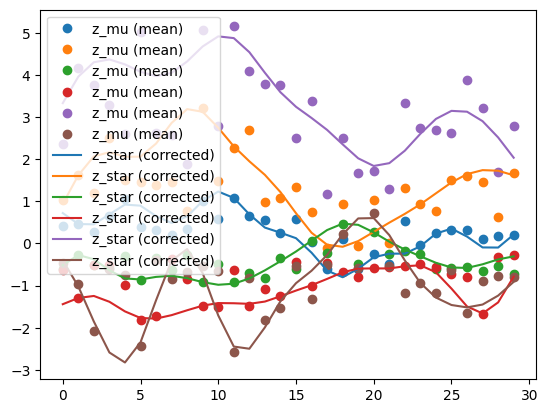

(-1.0, 3.0)

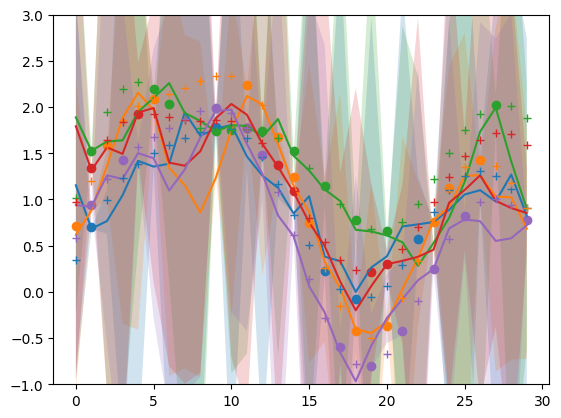

In [359]:

# Example usage
X[X!=X] = 0.
x_input, x_recon_mean, x_recon_min, x_recon_max = reconstruct_with_given_kernel_params(
    X[:10], [-1,0,-4,-2], gpvae
)

plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None);
plt.plot(x_recon_mean[0].detach());
plt.gca().set_prop_cycle(None);
for i in range(x_recon_mean.shape[2]):
    plt.fill_between(np.arange(30),
                    x_recon_min[0,:,i].detach(),
                    x_recon_max[0,:,i].detach(),
                    alpha = .2)
plt.plot(X_normalized[0],'+')
plt.ylim([-1,3])


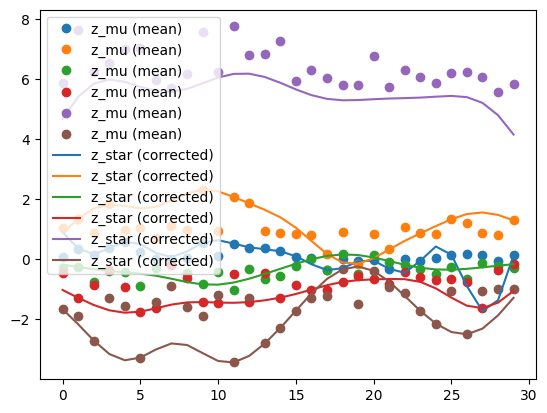

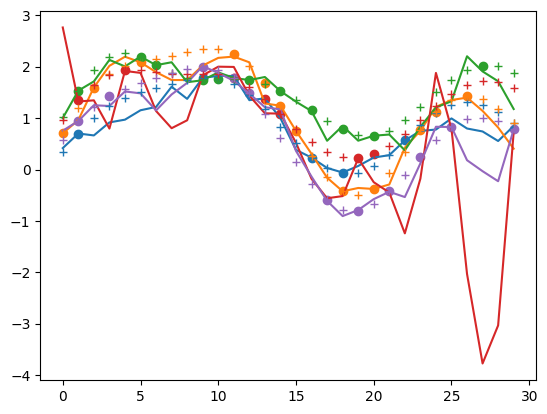

In [363]:
x_input, x_recon, _, _ = reconstruct_with_given_kernel_params(X[:10], [-1,0,-4,-2], gpvae)
plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None);
plt.plot(x_recon[0].detach());
plt.gca().set_prop_cycle(None);
plt.plot(X_normalized[0],'+')

In [356]:
gpvae.fit_kernel(dataset_train, dataset_val)  # train the model on the dataset

fitting kernel


Epoch 1/20: 11it [00:01,  6.78it/s]


Epoch 1/20: Average Loss = 0.300333


Epoch 2/20: 11it [00:01,  6.57it/s]


Epoch 2/20: Average Loss = 0.307404


...

Epoch 3/20: Average Loss = 0.305177


Epoch 4/20: 11it [00:01,  6.78it/s]


Epoch 4/20: Average Loss = 0.303272


Epoch 5/20: 5it [00:00,  6.32it/s]


KeyboardInterrupt: 

In [44]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE_posterior_concistency
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae_pc = GP_VAE_posterior_concistency(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 10, 
            epochs = 200, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (128,64,32), 
            decoder_sizes = (128,32),
            optimizer = Adam(weight_decay=0.001) #lr = 1e-4
            )

gpvae_pc.model.backbone.alpha = 1e-1
gpvae_pc.model.backbone.beta = 1e-2
gpvae_pc.model.backbone.gamma = 5 * 1e-5
gpvae_pc.model.backbone.noise_sigma = 1e-3
gpvae_pc.model.backbone.sampling = False
gpvae_pc.model.backbone.use_mean = True
gpvae_pc.model.backbone.p = 0.3
gpvae_pc.model.backbone.detach = True


# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae_pc.model.backbone.device = 'cpu'
gpvae_pc.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-02-20 16:01:49 [INFO]: No given device, using default device: cpu
2025-02-20 16:01:49 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-20 16:01:49 [INFO]: GP_VAE_posterior_concistency initialized with the given hyperparameters, the number of trainable parameters: 18,105


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=10, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=10, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


2025-02-20 16:01:53 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-02-20 16:01:53 [INFO]: Finished training. The best model is from epoch#-1.


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

In [361]:
gpvae.fit(dataset_train)  # train the model on the dataset

2025-02-24 11:23:48 [INFO]: Epoch 001 - training loss: 1.0329
2025-02-24 11:23:48 [INFO]: Epoch 002 - training loss: 1.0289
2025-02-24 11:23:49 [INFO]: Epoch 003 - training loss: 1.0284
2025-02-24 11:23:49 [INFO]: Epoch 004 - training loss: 1.0186
2025-02-24 11:23:50 [INFO]: Epoch 005 - training loss: 1.0128
2025-02-24 11:23:50 [INFO]: Epoch 006 - training loss: 1.0105
2025-02-24 11:23:50 [INFO]: Epoch 007 - training loss: 1.0299
2025-02-24 11:23:50 [INFO]: Epoch 008 - training loss: 1.0270
2025-02-24 11:23:50 [INFO]: Epoch 009 - training loss: 0.9982
2025-02-24 11:23:51 [INFO]: Epoch 010 - training loss: 1.0052
2025-02-24 11:23:51 [INFO]: Epoch 011 - training loss: 1.0132
2025-02-24 11:23:52 [INFO]: Epoch 012 - training loss: 0.9837
2025-02-24 11:23:52 [INFO]: Epoch 013 - training loss: 0.9946
2025-02-24 11:23:53 [INFO]: Epoch 014 - training loss: 1.0015
2025-02-24 11:23:53 [INFO]: Epoch 015 - training loss: 0.9821
2025-02-24 11:23:53 [INFO]: Epoch 016 - training loss: 0.9835
2025-02-

Plotting latent series and reconstruction...


2025-02-24 11:23:55 [INFO]: Epoch 019 - training loss: 0.9789
2025-02-24 11:23:55 [INFO]: Epoch 020 - training loss: 0.9797
2025-02-24 11:23:55 [INFO]: Epoch 021 - training loss: 0.9892
2025-02-24 11:23:55 [INFO]: Epoch 022 - training loss: 0.9577
2025-02-24 11:23:56 [INFO]: Epoch 023 - training loss: 0.9661
2025-02-24 11:23:56 [INFO]: Epoch 024 - training loss: 0.9681
2025-02-24 11:23:56 [INFO]: Epoch 025 - training loss: 0.9555
2025-02-24 11:23:57 [INFO]: Epoch 026 - training loss: 0.9683
2025-02-24 11:23:57 [INFO]: Epoch 027 - training loss: 0.9428
2025-02-24 11:23:57 [INFO]: Epoch 028 - training loss: 0.9409
2025-02-24 11:23:58 [INFO]: Epoch 029 - training loss: 0.9620
2025-02-24 11:23:58 [INFO]: Epoch 030 - training loss: 0.9699
2025-02-24 11:23:58 [INFO]: Epoch 031 - training loss: 0.9293
2025-02-24 11:23:59 [INFO]: Epoch 032 - training loss: 0.9266
2025-02-24 11:23:59 [INFO]: Epoch 033 - training loss: 0.9299
2025-02-24 11:23:59 [INFO]: Epoch 034 - training loss: 0.9137
2025-02-

Plotting latent series and reconstruction...


2025-02-24 11:24:18 [INFO]: Epoch 091 - training loss: 0.7455
2025-02-24 11:24:18 [INFO]: Epoch 092 - training loss: 0.7456
2025-02-24 11:24:18 [INFO]: Epoch 093 - training loss: 0.7384
2025-02-24 11:24:18 [INFO]: Epoch 094 - training loss: 0.7325
2025-02-24 11:24:18 [INFO]: Epoch 095 - training loss: 0.7262
2025-02-24 11:24:19 [INFO]: Epoch 096 - training loss: 0.7324
2025-02-24 11:24:19 [INFO]: Epoch 097 - training loss: 0.7604
2025-02-24 11:24:19 [INFO]: Epoch 098 - training loss: 0.7318
2025-02-24 11:24:20 [INFO]: Epoch 099 - training loss: 0.7412
2025-02-24 11:24:20 [INFO]: Epoch 100 - training loss: 0.7190
2025-02-24 11:24:21 [INFO]: Epoch 101 - training loss: 0.7234
2025-02-24 11:24:21 [INFO]: Epoch 102 - training loss: 0.7271
2025-02-24 11:24:21 [INFO]: Epoch 103 - training loss: 0.7155
2025-02-24 11:24:21 [INFO]: Epoch 104 - training loss: 0.7108
2025-02-24 11:24:22 [INFO]: Epoch 105 - training loss: 0.6832
2025-02-24 11:24:22 [INFO]: Epoch 106 - training loss: 0.7050
2025-02-

...

2025-02-24 11:28:24 [INFO]: Epoch 819 - training loss: -0.7755
2025-02-24 11:28:24 [INFO]: Epoch 820 - training loss: -0.7799
2025-02-24 11:28:24 [INFO]: Epoch 821 - training loss: -0.7797
2025-02-24 11:28:24 [INFO]: Epoch 822 - training loss: -0.7825
2025-02-24 11:28:25 [INFO]: Epoch 823 - training loss: -0.7823
2025-02-24 11:28:25 [INFO]: Epoch 824 - training loss: -0.7841
2025-02-24 11:28:25 [INFO]: Epoch 825 - training loss: -0.7866
2025-02-24 11:28:25 [INFO]: Epoch 826 - training loss: -0.7899
2025-02-24 11:28:26 [INFO]: Epoch 827 - training loss: -0.7901
2025-02-24 11:28:27 [INFO]: Epoch 828 - training loss: -0.7865
2025-02-24 11:28:27 [INFO]: Epoch 829 - training loss: -0.7909
2025-02-24 11:28:27 [INFO]: Epoch 830 - training loss: -0.7900
2025-02-24 11:28:27 [INFO]: Epoch 831 - training loss: -0.7857
2025-02-24 11:28:28 [INFO]: Epoch 832 - training loss: -0.7929
2025-02-24 11:28:28 [INFO]: Epoch 833 - training loss: -0.7813
2025-02-24 11:28:29 [INFO]: Epoch 834 - training loss: 

Plotting latent series and reconstruction...


2025-02-24 11:28:52 [INFO]: Epoch 891 - training loss: -0.8238
2025-02-24 11:28:52 [INFO]: Epoch 892 - training loss: -0.8232
2025-02-24 11:28:52 [INFO]: Epoch 893 - training loss: -0.8266
2025-02-24 11:28:53 [INFO]: Epoch 894 - training loss: -0.8292
2025-02-24 11:28:53 [INFO]: Epoch 895 - training loss: -0.8246
2025-02-24 11:28:54 [INFO]: Epoch 896 - training loss: -0.8291
2025-02-24 11:28:54 [INFO]: Epoch 897 - training loss: -0.8263
2025-02-24 11:28:54 [INFO]: Epoch 898 - training loss: -0.8291
2025-02-24 11:28:54 [INFO]: Epoch 899 - training loss: -0.8263
2025-02-24 11:28:55 [INFO]: Epoch 900 - training loss: -0.8331
2025-02-24 11:28:55 [INFO]: Epoch 901 - training loss: -0.8287
2025-02-24 11:28:56 [INFO]: Epoch 902 - training loss: -0.8292
2025-02-24 11:28:56 [INFO]: Epoch 903 - training loss: -0.8375
2025-02-24 11:28:56 [INFO]: Epoch 904 - training loss: -0.8363
2025-02-24 11:28:57 [INFO]: Epoch 905 - training loss: -0.8335
2025-02-24 11:28:57 [INFO]: Epoch 906 - training loss: 

Plotting latent series and reconstruction...


2025-02-24 11:29:17 [INFO]: Epoch 964 - training loss: -0.8578
2025-02-24 11:29:17 [INFO]: Epoch 965 - training loss: -0.8602
2025-02-24 11:29:17 [INFO]: Epoch 966 - training loss: -0.8566
2025-02-24 11:29:18 [INFO]: Epoch 967 - training loss: -0.8645
2025-02-24 11:29:18 [INFO]: Epoch 968 - training loss: -0.8641
2025-02-24 11:29:18 [INFO]: Epoch 969 - training loss: -0.8654
2025-02-24 11:29:19 [INFO]: Epoch 970 - training loss: -0.8627
2025-02-24 11:29:19 [INFO]: Epoch 971 - training loss: -0.8629
2025-02-24 11:29:19 [INFO]: Epoch 972 - training loss: -0.8652
2025-02-24 11:29:20 [INFO]: Epoch 973 - training loss: -0.8634
2025-02-24 11:29:20 [INFO]: Epoch 974 - training loss: -0.8638
2025-02-24 11:29:20 [INFO]: Epoch 975 - training loss: -0.8618
2025-02-24 11:29:20 [INFO]: Epoch 976 - training loss: -0.8644
2025-02-24 11:29:20 [INFO]: Epoch 977 - training loss: -0.8644
2025-02-24 11:29:21 [INFO]: Epoch 978 - training loss: -0.8584
2025-02-24 11:29:21 [INFO]: Epoch 979 - training loss: 

In [325]:
gpvae.fit_kernel(dataset_train, dataset_val)  # train the model on the dataset

fitting kernel


Epoch 1/20: 11it [00:01,  6.48it/s]


Epoch 1/20: Average Loss = 0.148989


Epoch 2/20: 11it [00:01,  6.75it/s]


Epoch 2/20: Average Loss = 0.153854


...

Epoch 4/20: Average Loss = 0.152017


Epoch 5/20: 11it [00:01,  6.70it/s]


Epoch 5/20: Average Loss = 0.153269


Epoch 6/20: 2it [00:00,  4.47it/s]


KeyboardInterrupt: 

torch.Size([30, 6])
torch.Size([1000, 30, 6]) torch.Size([1000, 30, 6]) torch.Size([1000, 30, 6])


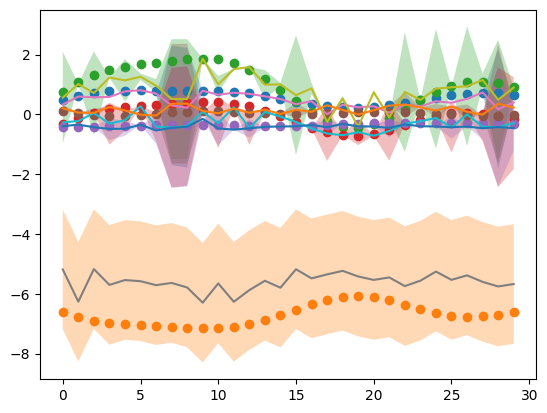

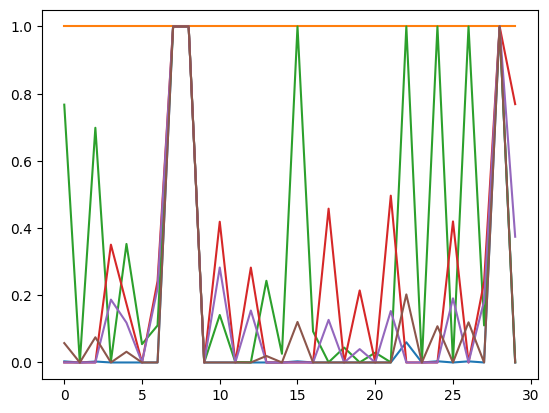

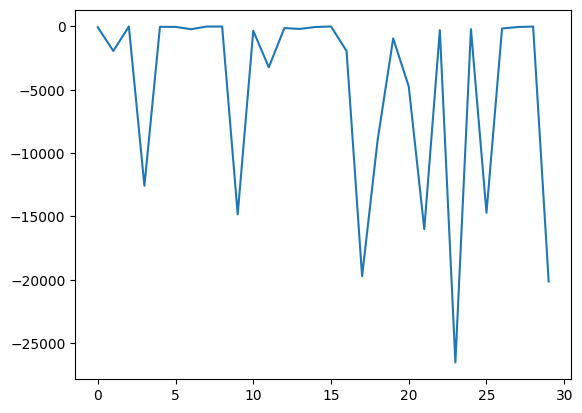

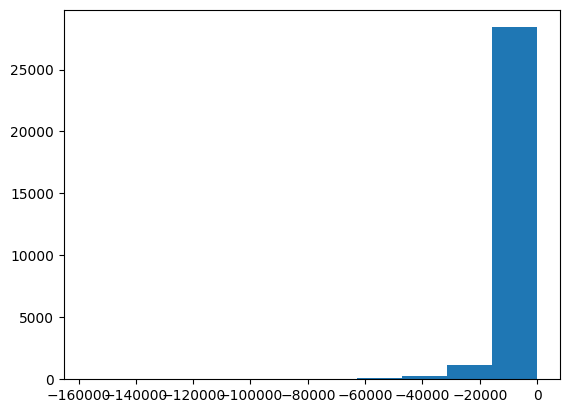

-5.3219879580380915

In [351]:
from benchmarking import compute_latent_log_probability
X[X!=X] = 0
compute_latent_log_probability(gpvae, X_normalized, X)

In [225]:
gpvae.fit_kernel(dataset_train)  # train the model on the dataset

fitting kernel


Epoch 1/20: 11it [00:02,  4.38it/s]


Epoch 1/20: Average Loss = 0.272356


Epoch 2/20: 11it [00:02,  4.39it/s]


Epoch 2/20: Average Loss = 0.273649


Epoch 3/20: 11it [00:02,  4.39it/s]


Epoch 3/20: Average Loss = 0.270420


Epoch 4/20: 3it [00:00,  3.96it/s]


KeyboardInterrupt: 

In [709]:
#p_dataset = .3
alpha = 1
beta = 1
gamma = 1e-10
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/2774675125.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvae = torch.load(f'gvpae_p_dataset_{p_datas

In [770]:
gpvae.model.backbone.gamma = 1e-5
gpvae.model.backbone.alpha = 1e1

gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2024-12-10 17:04:42 [INFO]: Epoch 001 - training loss: 17.5849, validation loss: 0.1250
2024-12-10 17:04:50 [INFO]: Epoch 002 - training loss: 8.5671, validation loss: 0.1135


plotting


2024-12-10 17:04:58 [INFO]: Epoch 003 - training loss: 7.8250, validation loss: 0.1085
2024-12-10 17:05:06 [INFO]: Epoch 004 - training loss: 7.5778, validation loss: 0.1035
2024-12-10 17:05:13 [INFO]: Epoch 005 - training loss: 7.4117, validation loss: 0.1004
2024-12-10 17:05:21 [INFO]: Epoch 006 - training loss: 7.3101, validation loss: 0.0966
2024-12-10 17:05:28 [INFO]: Epoch 007 - training loss: 7.1979, validation loss: 0.0937
2024-12-10 17:05:35 [INFO]: Epoch 008 - training loss: 7.1248, validation loss: 0.0922
2024-12-10 17:05:42 [INFO]: Epoch 009 - training loss: 7.0624, validation loss: 0.0899
2024-12-10 17:05:49 [INFO]: Epoch 010 - training loss: 6.9653, validation loss: 0.0876
2024-12-10 17:05:56 [INFO]: Epoch 011 - training loss: 6.8829, validation loss: 0.0863
2024-12-10 17:06:03 [INFO]: Epoch 012 - training loss: 6.8098, validation loss: 0.0848


plotting


2024-12-10 17:06:12 [INFO]: Epoch 013 - training loss: 6.7548, validation loss: 0.0841
2024-12-10 17:06:19 [INFO]: Epoch 014 - training loss: 6.6994, validation loss: 0.0839
2024-12-10 17:06:26 [INFO]: Epoch 015 - training loss: 6.6823, validation loss: 0.0850
2024-12-10 17:06:32 [INFO]: Epoch 016 - training loss: 6.6709, validation loss: 0.0842
2024-12-10 17:06:38 [INFO]: Epoch 017 - training loss: 6.6743, validation loss: 0.0831
2024-12-10 17:06:44 [INFO]: Epoch 018 - training loss: 6.6901, validation loss: 0.0837
2024-12-10 17:06:51 [INFO]: Epoch 019 - training loss: 6.7245, validation loss: 0.0834
2024-12-10 17:06:56 [INFO]: Epoch 020 - training loss: 6.7463, validation loss: 0.0835
2024-12-10 17:07:02 [INFO]: Epoch 021 - training loss: 6.6478, validation loss: 0.0842
2024-12-10 17:07:08 [INFO]: Epoch 022 - training loss: 6.5334, validation loss: 0.0846


...

2024-12-10 17:07:16 [INFO]: Epoch 023 - training loss: 6.4253, validation loss: 0.0842
2024-12-10 17:07:22 [INFO]: Epoch 024 - training loss: 6.4058, validation loss: 0.0864
2024-12-10 17:07:29 [INFO]: Epoch 025 - training loss: 6.3883, validation loss: 0.0866
2024-12-10 17:07:36 [INFO]: Epoch 026 - training loss: 6.4149, validation loss: 0.0864
2024-12-10 17:07:45 [INFO]: Epoch 027 - training loss: 6.4422, validation loss: 0.0886
2024-12-10 17:07:52 [INFO]: Epoch 028 - training loss: 6.3668, validation loss: 0.0864
2024-12-10 17:07:57 [INFO]: Epoch 029 - training loss: 6.1779, validation loss: 0.0888
2024-12-10 17:08:05 [INFO]: Epoch 030 - training loss: 6.1805, validation loss: 0.0892
2024-12-10 17:08:11 [INFO]: Epoch 031 - training loss: 6.1648, validation loss: 0.0917
2024-12-10 17:08:17 [INFO]: Epoch 032 - training loss: 6.0616, validation loss: 0.0898


plotting


2024-12-10 17:08:25 [INFO]: Epoch 033 - training loss: 5.8751, validation loss: 0.0914
2024-12-10 17:08:32 [INFO]: Epoch 034 - training loss: 5.9607, validation loss: 0.0992
2024-12-10 17:08:39 [INFO]: Epoch 035 - training loss: 5.7205, validation loss: 0.0922
2024-12-10 17:08:46 [INFO]: Epoch 036 - training loss: 5.6364, validation loss: 0.0931
2024-12-10 17:08:52 [INFO]: Epoch 037 - training loss: 5.6711, validation loss: 0.0947
2024-12-10 17:08:59 [INFO]: Epoch 038 - training loss: 5.7052, validation loss: 0.0964
2024-12-10 17:09:05 [INFO]: Epoch 039 - training loss: 5.6887, validation loss: 0.0961
2024-12-10 17:09:11 [INFO]: Epoch 040 - training loss: 5.7144, validation loss: 0.0982
2024-12-10 17:09:18 [INFO]: Epoch 041 - training loss: 5.6846, validation loss: 0.1001
2024-12-10 17:09:25 [INFO]: Epoch 042 - training loss: 5.7759, validation loss: 0.0981
2024-12-10 17:09:33 [INFO]: Epoch 043 - training loss: 5.7194, validation loss: 0.1045


plotting


2024-12-10 17:09:44 [INFO]: Epoch 044 - training loss: 5.7539, validation loss: 0.1027
2024-12-10 17:09:51 [INFO]: Epoch 045 - training loss: 5.7991, validation loss: 0.1013
2024-12-10 17:09:58 [INFO]: Epoch 046 - training loss: 5.8195, validation loss: 0.1039
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1063492e0>>
Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
2024-12-10 17:10:06 [INFO]: Epoch 047 - training loss: 5.7591, validation loss: 0.1034
2024-12-10 17:10:08 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-12-10 17:10:08 [INFO]: Finished training. The best model is from epoch#17.


In [230]:
X[X!=X] = 0

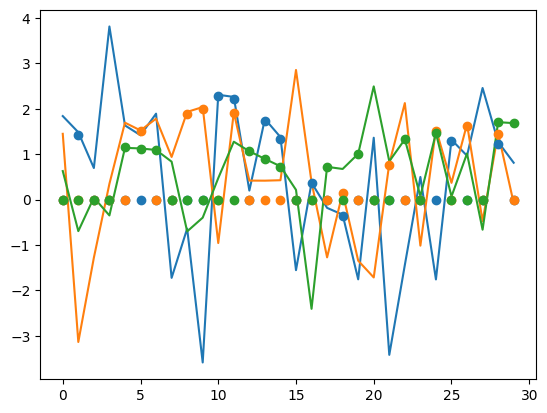

In [294]:
import torch

qz_x = gpvae.model.backbone.encode(torch.tensor(X).float())
z = qz_x.rsample()
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.gca().set_prop_cycle(None)
plt.plot(X[0],'o')
plt.show();

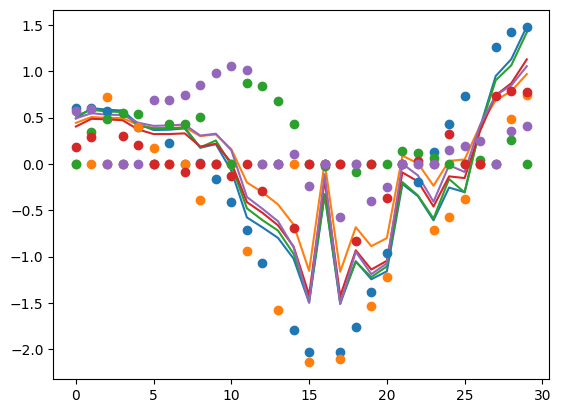

In [183]:
import torch

qz_x = gpvae_pc.model.backbone.encode(torch.tensor(X).float())
z = qz_x.mean
X_recon = gpvae_pc.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.gca().set_prop_cycle(None)
plt.plot(X[0],'o')
plt.show();

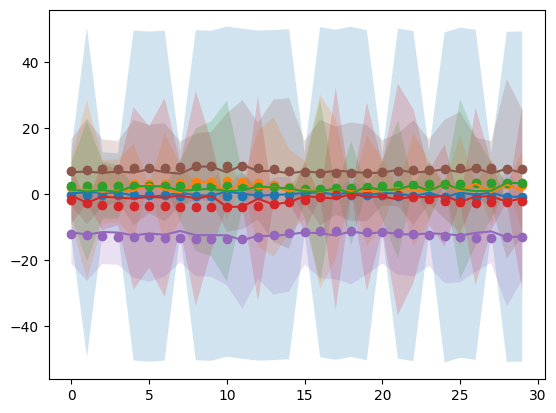

In [304]:
x_input_ori = torch.tensor(X_normalized).float()

qz_x = gpvae.model.backbone.encode(x_input_ori)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

plt.plot(z_mu[0].detach(),'o')

plt.gca().set_prop_cycle(None)

X[X!=X] = 0.
x_input = torch.tensor(X).float()
qz_x = gpvae.model.backbone.encode(x_input)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

mean = z_mu[0].detach()
var = z_var[0].detach()
plt.plot(mean)
for i in range(mean.shape[1]):
    plt.fill_between(np.arange(mean.shape[0]),
                    mean[:,i]-2*var[:,i], 
                    mean[:,i]+2*var[:,i],
                    alpha = 0.2)




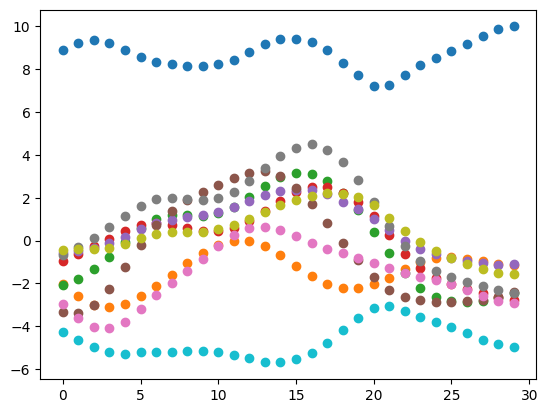

In [262]:
x_input = torch.tensor(X_ori).float()

qz_x = gpvae.model.backbone.encode(x_input)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

plt.plot(z_mu[0].detach(),'o')
plt.gca().set_prop_cycle(None)

m, v = gpvae.backbone.encode(dataset_val['X_ori'][:2])


print(m)

KeyError: 'X_normalized'

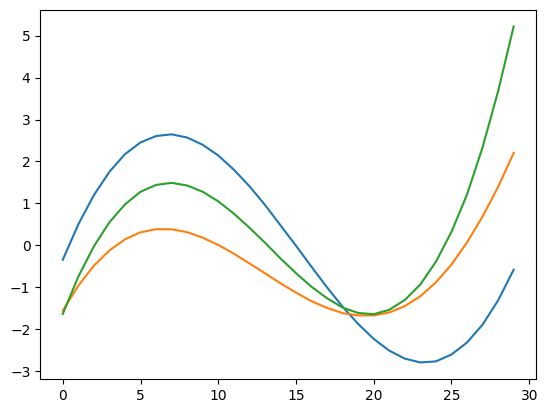

In [303]:
with torch.autograd.set_detect_anomaly(True):
    imputation = gpvae.impute(dataset_val, with_gp = True)

plt.plot(imputation[0]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X_ori'][0],'+')
plt.gca().set_prop_cycle(None)
x_observed = dataset_val['X'][0]
x_observed[x_observed==0] = np.nan
plt.plot(x_observed,'o');

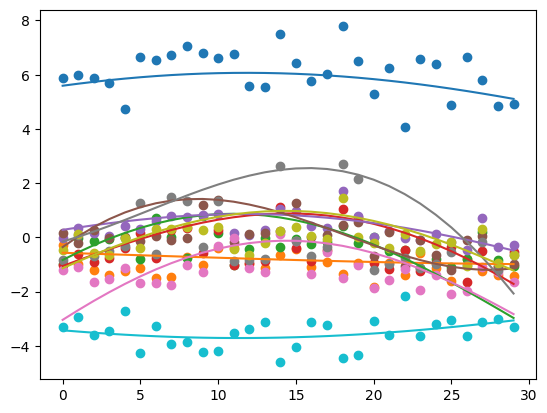

In [244]:
def reconstruct_with_given_kernel_params(X, kernel_params, gpvae):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)

    #print(z_mu[:2].shape, z_var[:2].shape)

    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star, z_star_var = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params, return_variance = True)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean


    x_input[x_input==0] = torch.nan

    return x_input, x_recon

x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [0.00001,1,.001,0], gpvae)


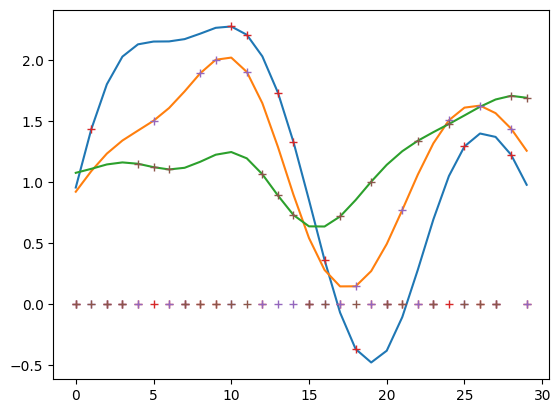

In [302]:
plt.plot(X_normalized[0])
plt.plot(X[0],'+')

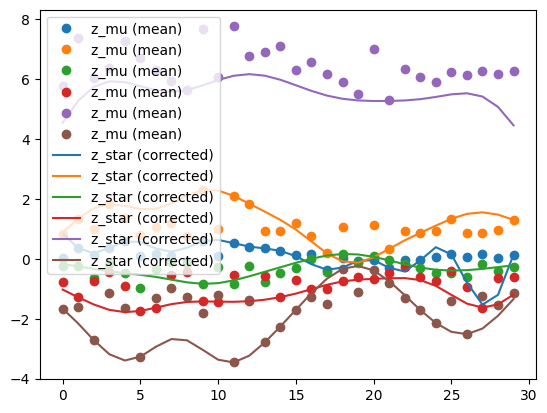

ValueError: too many values to unpack (expected 2)

In [362]:
x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [-1,0,-4,-2], gpvae)
plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None)
plt.plot(x_recon[0].detach());

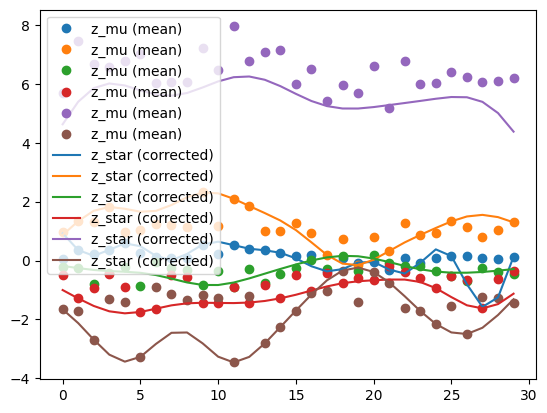

ValueError: too many values to unpack (expected 2)

In [364]:
x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [-1,0,-4,-2], gpvae_pc)
plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None)
plt.plot(x_recon[0].detach());

In [826]:
gpvaee = torch.load('gvpae_p_dataset_0.9-a_1_b_0.1_gamma_1e-10')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/1547841420.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvaee = torch.load('gvpae_p_dataset_0.9-a_1_

In [827]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = 10, latent_size = 30)
#gpvae.optimizer.lr = 1e-4

In [828]:
gpvae.gp.p = 0.1

In [829]:
gpvae.fit_kernel(dataset_train)  # train the model on the dataset

fitting kernel


Epoch 1/20: 55it [00:33,  1.64it/s]


Epoch 1/20: Average Loss = 0.112911


Epoch 2/20: 55it [00:36,  1.51it/s]


Epoch 2/20: Average Loss = 0.106313


...

Epoch 18/20: Average Loss = 0.069268


Epoch 19/20: 55it [00:36,  1.49it/s]


Epoch 19/20: Average Loss = 0.067511


Epoch 20/20: 55it [00:37,  1.48it/s]

Epoch 20/20: Average Loss = 0.067032


In [830]:
X_torch = torch.tensor(X).float()[:10]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)

X_recon = gpvae.model.backbone.decode(embedding.mean).mean

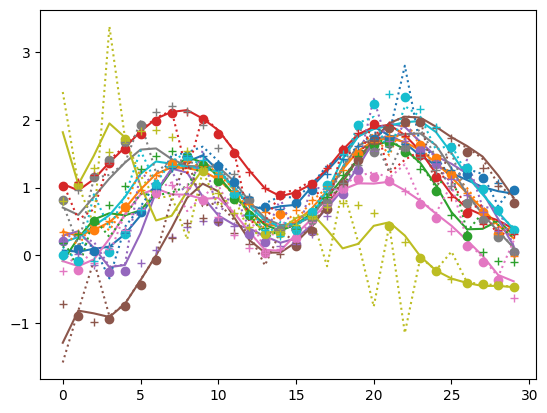

In [835]:
i = 2
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':', label = 'recon')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');

In [832]:
gpvae.predict(dataset_val)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/4179161113.py", line 1, in <module>
    gpvae.predict(dataset_val)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 473, in predict
    embedding = self.model.encode(inputs, training=False, n_sampling_times=n_sampling_times)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/core.py", line 124, in encode
    return self.backbone.encode(data)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py", line 144, in encode
    return self.encoder(x, missing_mask)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553

fitting kernel


Epoch 1/50: 157it [00:04, 32.10it/s]


Epoch 1/50: Average Loss = 15212.884736


Epoch 2/50: 157it [00:04, 34.63it/s]


Epoch 2/50: Average Loss = 49.249578


...

Epoch 22/50: 157it [00:04, 33.36it/s]


Epoch 22/50: Average Loss = 1.192580


Epoch 23/50: 47it [00:01, 33.53it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/4127550510.py", line 1, in <module>
    gpvae.fit_kernel(dataset)  # train the model on the dataset
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 540, in fit_kernel
    self._fit_kernel(training_loader)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 510, in _fit_kernel
    self.gp.fit_kernel(training_loader)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/gp_model.py", line 409, in fit_kernel
    z_star = self.correct_with_gp(z_mu, z_var, kernel_params)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/gp_model.

## RUN THIS

In [ ]:
gpvae.model.backbone.p = 0.1

gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
## Assess reconstruction error
import torch

z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
X_recon = gpvae.model.backbone.decoder(z).mean

error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean()

print(error)

In [ ]:
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.1
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.p = .3
gpvae.model.backbone.sampling = True
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
import gpytorch
import torch
with gpytorch.settings.cholesky_jitter(1e-4):
    with torch.autograd.set_detect_anomaly(True):
        gpvae.fit_kernel(dataset)  # train the model on the dataset


In [ ]:
gpvae.gp.gp_models[0].covar_module.outputscale


In [ ]:
help(gpvae.gp.gp_models[0].covar_module)


In [ ]:
import torch
x = torch.ones((8,48))
gpvae.gp.gp_models[0](x)

In [ ]:
gpvae.gp._fit_kernel

In [ ]:
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GPVAE
from pypots.utils.metrics import calc_mae
gpvae = GPVAE(n_steps=48, n_features=37, latent_size = 12, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import SAITS
from pypots.utils.metrics import calc_mae
gpvae = SAITS(n_steps=48, n_features=37, n_layers=2, d_model=256, n_heads=4, d_k=64, d_v=64, d_ffn=128, dropout=0.1, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/saits_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/saits_physionet2012.pypots")  # reload the serialized model file for following imputation or training